In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [11]:
# Load data
df = pd.read_csv('multiple_regression_analysis.csv')

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


In [13]:
df.describe()

,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


In [14]:
# Check Missing Values
df.isnull().sum

<bound method DataFrame.sum of         TV  Radio  Social Media  Influencer  Sales
0    False  False         False       False  False
1    False  False         False       False  False
2    False  False         False       False  False
3    False  False         False       False  False
4    False  False         False       False  False
..     ...    ...           ...         ...    ...
567  False  False         False       False  False
568  False  False         False       False  False
569  False  False         False       False  False
570  False  False         False       False  False
571  False  False         False       False  False

[572 rows x 5 columns]>

In [ ]:
Exploratory Data Analysis

In [ ]:
Distribution of Sales

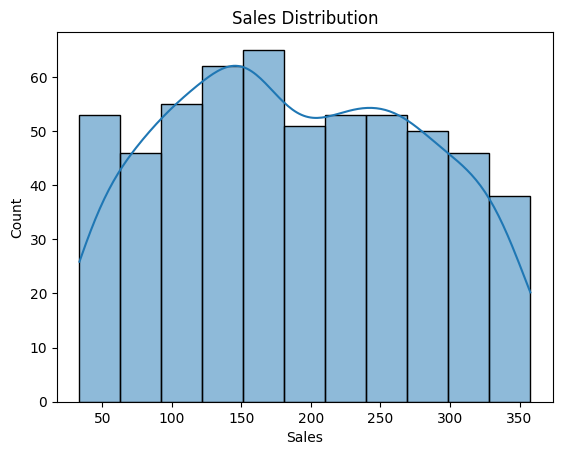

In [21]:
sns.histplot(df['Sales'], kde=True)
plt.title('Sales Distribution')
plt.show()

In [ ]:
Convert Categorical Variables
Since TV and Influencer are categorical, use One-Hot Encoding.

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=['TV', 'Influencer'],
    drop_first=True
)

In [23]:
df_encoded.head()

,Radio,Social Media,Sales,TV_Low,TV_Medium,Influencer_Mega,Influencer_Micro,Influencer_Nano
0,3.518070,2.293790,55.261284,True,False,False,True,False
1,7.756876,2.572287,67.574904,True,False,True,False,False
2,20.348988,1.227180,272.250108,False,False,False,True,False
3,20.108487,2.728374,195.102176,False,True,True,False,False
4,31.653200,7.776978,273.960377,False,False,False,False,True


In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=['TV', 'Influencer'],
    drop_first=True
)

df_encoded = df_encoded.astype(float)

In [ ]:
Correlation Matrix

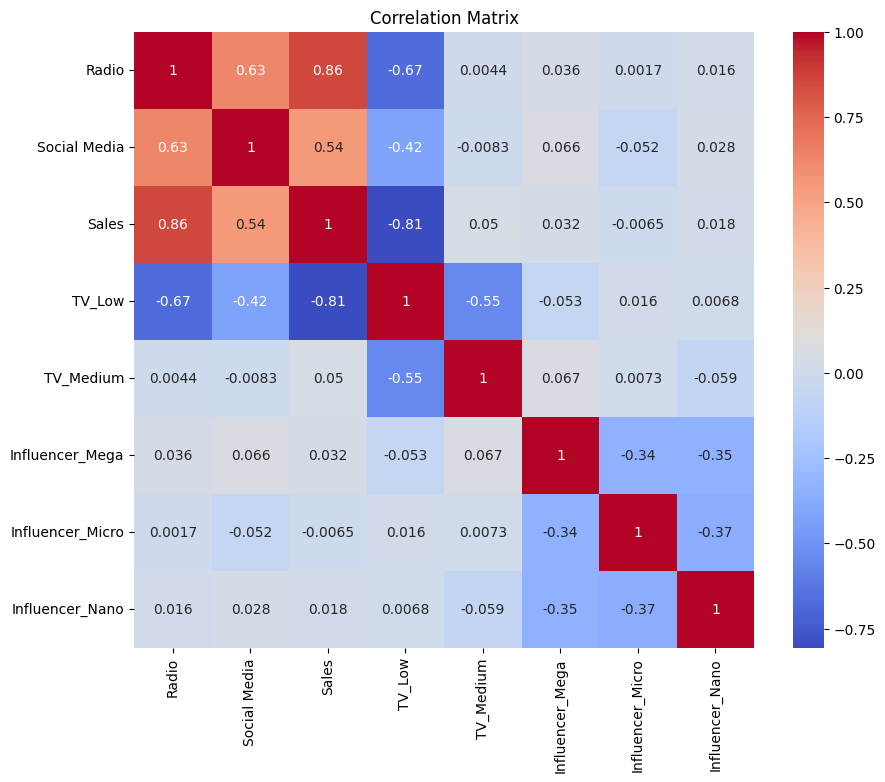

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
Check Multicollinearity Using VIF

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df_encoded.drop('Sales', axis=1)

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

           Variable        VIF
0             const  31.649565
1             Radio   3.479641
2      Social Media   1.669098
3            TV_Low   4.076384
4         TV_Medium   2.233350
5   Influencer_Mega   1.593889
6  Influencer_Micro   1.618434
7   Influencer_Nano   1.627430


In [ ]:
Build Regression Model

In [35]:
print(df_encoded.columns.tolist())

['Radio', 'Social Media', 'Sales', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']


In [37]:
X = df_encoded[['Radio', 'Social Media', 'TV_Low', 'TV_Medium', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']]
y = df_encoded ['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 09 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        12:12:15   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

In [ ]:
Predicted Values and Residuals

In [38]:
predictions = model.predict(X)

residuals = y - predictions

In [ ]:
Residuals Vs Fitted Plot

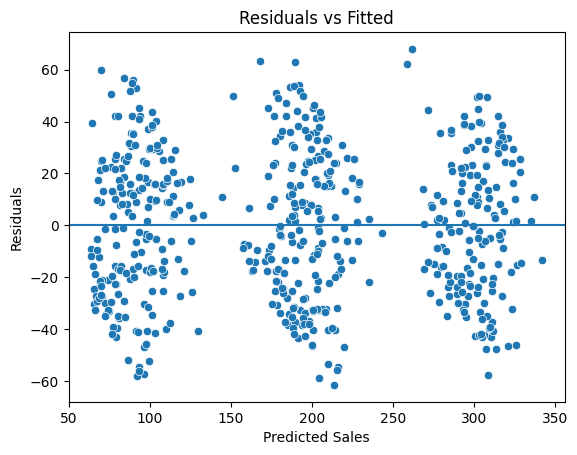

In [39]:
sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(0)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted")

plt.show()

In [ ]:
Q-Q Plot

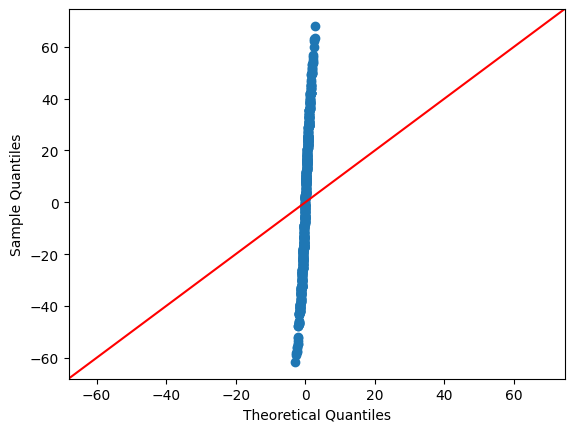

In [40]:
sm.qqplot(residuals, line='45')

plt.show()

In [ ]:
Histogram

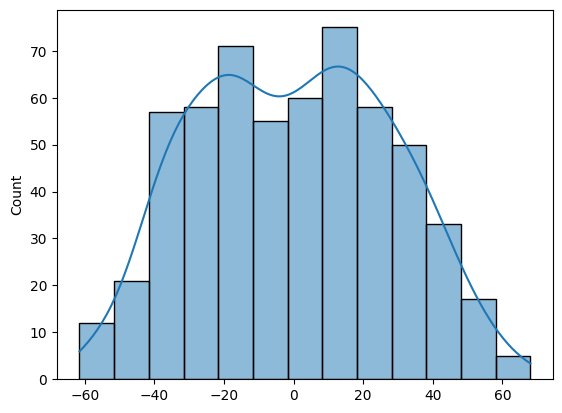

In [41]:
sns.histplot(
    residuals,
    kde=True
)

plt.show()